# Logistic Regression 

정석적인 설명은 아니다. 

느낌만!

토익, 텝스 예제로 돌아오자. 

In [2]:
import rpy2
%load_ext rpy2.ipython

In [3]:
%%R 
set.seed(9999)
n<-1000
toeic<-750+rnorm(n,sd=80)
toeic[toeic>990]<-990
toeic<-round(toeic)
gpa<-3.5+rnorm(n,sd=0.3)
gpa[gpa>4.5]<-4.5 
gpa<-round(gpa,1)
sal<-gpa*600+toeic*5+rnorm(n,sd=80)
sal<-round(sal)

In [4]:
%%R 
head(sal)

[1] 6276 5979 5910 5758 7098 6344


데이터를 조금 바꾸어서 $y$를 연봉이 아니라 합격 or 불합격으로 생각하자. 

In [5]:
%%R
mean(sal)

[1] 5854.538


구 예제에서 연봉이 5850미만인 사람은 불합격이라고 가정하고, 연봉이 5850이상인 사람은 합격이라고 하자 

In [6]:
%%R 
set.seed(3)
n<-1000
toeic<-750+rnorm(n,sd=80)
toeic[toeic>990]<-990
toeic<-round(toeic)
gpa<-3.5+rnorm(n,sd=0.3)
gpa[gpa>4.5]<-4.5 
gpa<-round(gpa,1)
temp<-gpa*600+toeic*5+rnorm(n,sd=80)
employed<- (temp>5850)*1

R[write to console]: ── Attaching packages ─────────────────────────────────────── tidyverse 1.3.0 ──

R[write to console]: ✔ ggplot2 3.3.3     ✔ purrr   0.3.4
✔ tibble  3.0.6     ✔ dplyr   1.0.6
✔ tidyr   1.1.2     ✔ stringr 1.4.0
✔ readr   1.4.0     ✔ forcats 0.5.1

R[write to console]: ── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()



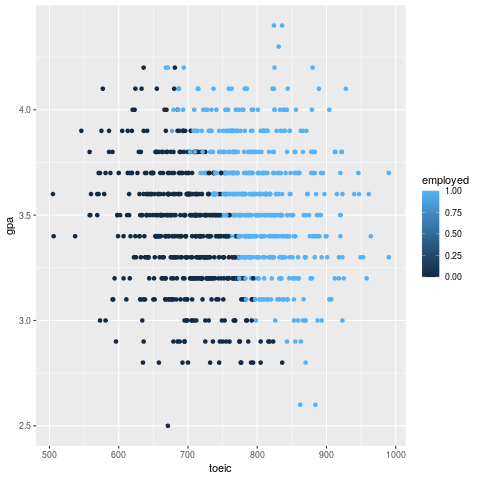

In [7]:
%%R
library(tidyverse)
tb<-tibble(toeic=toeic,gpa=gpa,employed=employed)
library(ggplot2)
ggplot(data=tb,aes(x=toeic,y=gpa))+geom_point(aes(col=employed))

## 1. Structure: Step function $\to$ Sigmoid function

진짜모형: 

(1) 학점이 높을수록 그리고 토익점수가 높을수록 합격할 확률이 높다. 

(2) 구체적으로는 아래와 같다. 
 - `(gpa*600 +toeic*5 + 랜덤) > 5850` 이면 합격
 - `(gpa*600 +toeic*5 + 랜덤) =< 5850` 이면 불합격

(3) 식으로 엄밀하게 써보면 아래와 같다. 

모든 $i=1,\dots,1000$에 대하여

$y_i = I(x_{i1}\times 600 + x_{2i}\times 5 +\epsilon_i > 5850)$

정리하면 

$y_i = I(x_{i1}\times 600 + x_{2i}\times 5 +\epsilon_i - 5850 >0)$

단, $I(x>0)=\begin{cases}1 & x>0 \\ 0 & x \leq 0  \end{cases}$.

(4) 우리는 $data=\big\{(x_{i1},x_{i2},y_i)\big\}_{i=1}^{1000}$를 알고 있고, data로 부터 추론할것은 바로

- 600 
- 5
- -5850

이라는 숫자들이다. 

(5) 논의를 편하게 하기 위해서 앞으로는 600이라는 값을 알고 있다고 가정하자. 그리고 5와 5500을 추론하기만 하면 된다고 하자. 

(6) 문제는 아래와 같이 단순화 된다.

모든 $i=1,2,\dots,5850$에 대하여 

$
y_i=I(x_{i1}\beta_1+x_{i2}\times 5 +\epsilon_i > \gamma)
$

에서 $\beta_1$, $\gamma$를 추론해야 한다. $\epsilon_i$은 운적인 요소이므로 추론의 대상이 아님. 따라서

$
y_i\approx I(x_{i1}\beta_1+x_{i2}\times 5  > \gamma)
$

가 되도록 $\hat{\beta}_1$와 $\hat{\gamma}$을 잘 추론해야 한다. 

최소제곱법을 사용하자. 아래와 같은 손실함수 $L$을 정의하자. 

$L=\sum_{i=1}^{1000}\big(y_i-I(x_{i1}\beta_1+x_{i2}\times 5  > \gamma)\big)^2$

$L$을 최소화하는 $\beta_1$, $\gamma$를 구하자.

일반적으로 $L$을 각각 $\beta_1$, $\gamma$로 미분한뒤 그 값을 0으로 놓은 식을 연립하여 풀면 된다. 즉 아래를 풀면된다.

$\begin{cases}
\frac{\partial }{\partial \beta_1}L=0\\ 
\frac{\partial }{\partial \gamma}L=0
\end{cases}$

먼저 $\frac{\partial}{\partial \beta_1}L=0$을 살펴보자. 

$L=\big(y_1-I(x_{11}\beta_1+x_{12}\times 5  > \gamma)\big)^2+ \dots + \big(y_n-I(x_{n1}\beta_1+x_{n2}\times 5  > \gamma)\big)^2$, 단 $n=1000$.

미분하려고 보니까 $I$는 미분이 불가능한 함수이다. 

???

### 문제점: 미분을 못한다. 

우리는 뭘 연립해서 풀어야 하는가? 

### 해결책1

수치해석적인 노가다

가능한 모든 $\beta_1$과 $\gamma$의 조합을 생각한다. 

그리고 아래를 계산한다. 

$L=\sum_{i=1}^{n}\big(y_i-I(\beta_1x_{i1}+5x_{i2}-\gamma>0)\big)^2$

예를들어 $\beta_1=0.2$, $\gamma=200$을 넣고 위의 값을 계산할 수 있다. 편의상 그 값을 $L(0.2,200)$라고 하자. 

그리고 $\beta_1=10$, $\gamma=5000$을 넣고 계산할 수도 있다. 편의상 그 값을 $L(10,5000)$이라고 하자. 

우연히 $\beta_1=600$, $\gamma=5500$을 넣는다면 그 조합이 $L$을 최소화 할 것이다. 

즉 $L(600,5500)$이 $L(\beta,\gamma)$의 조합중 최소값일 것이다. 

### 해결책2 

미분불가능한함수를 미분가능한 어떤 함수로 바꾼다. 

미분 불가능한 부분은 현재 아래와 같은 함수의 형태이다. 

$
I(\beta_1x_{i1}+5x_{i2}-\gamma>0)
$

예를들어서 $i=1$이라고 치면 아래와 같은 함수이다.

$
I(\beta_1x_{11}+5x_{12}-\gamma>0)
$

그런데

$x_{11}=3.1$, $x_{12}=673$ 이므로 

In [8]:
%R print(gpa[1])
%R print(toeic[1])

[1] 3.6
[1] 673


array([673.])

아래와 같이 정리가능

$
I(\beta_1\times 3.1+5\times 673-\gamma>0)
$

이 함수의 모양은 계단형이다. 



(1) $\beta_1$을 고정 $\to$ $x$축에 $\gamma$, $y$축에 $I(\beta_1\times 3.1+5\times 673-\gamma>0)$를 그리면 계단모양이 된다. 

(2) $\gamma$을 고정 $\to$ $x$축에 $\beta_1$, $y$축에 $I(\beta_1\times 3.1+5\times 673-\gamma>0)$를 그리면 계단모양이 된다. 

***case1: beta1를 고정***

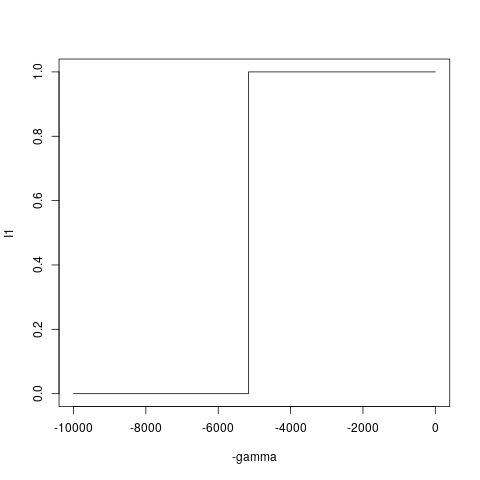

In [9]:
%%R
beta1=500
gamma=1:10000
I1 = 1*(gpa[1]*beta1+toeic[1]*5-gamma>0)
plot(-gamma,I1,type='l')

***case2: gamma를 고정***

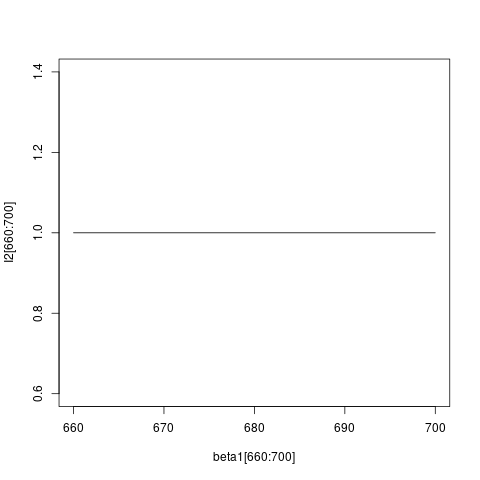

In [10]:
%%R
gamma=5500
beta1=1:1000
I2=1*(gpa[1]*beta1+toeic[1]*5-gamma>0)
plot(beta1[660:700],I2[660:700],type='l')

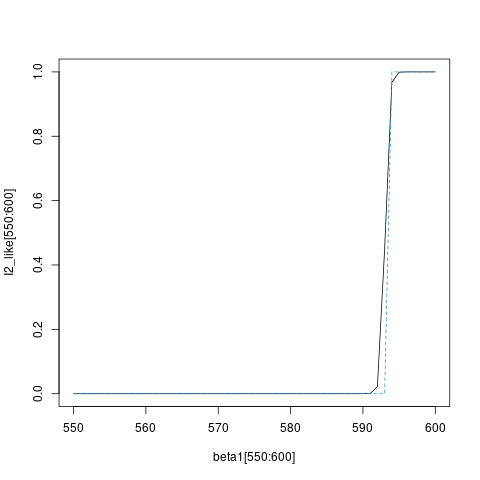

In [15]:
%%R 
gamma=5500
beta1=1:1000
yy<- gpa[1]*beta1+toeic[1]*5-gamma
I2_like<-exp(yy)/(1+exp(yy))
plot(beta1[550:600],I2_like[550:600],type='l')
lines(beta1[550:600],I2[550:600],col=4,lty=2)

비슷하다. 

${\tt yy}_i=x_{i1}\beta_1+x_{i2}\times 5 -\gamma$

${\tt I2like}=\frac{exp(x_{i1}\beta_1+x_{i2}\times 5-\gamma)}{1+exp(x_{i1}\beta_1+x_{i2}\times 5-\gamma)}$

---

원래 트루모형: 

$y_i=f(\beta_0+x_{i1}\beta_1+x_{i2}\beta_2+\epsilon_i)$

$f(x)=I(x)$

제안하는 모형:

$y_i=f(\beta_0+x_{i1}\beta_1+x_{i2}\beta_2+\epsilon_i)$

$f(x)=\frac{e^x}{1+e^x}=\frac{1}{1+e^{-x}}$

왜? 

(1) $\frac{e^x}{1+e^x}$는 $x$로 미분이 가능하며 

(2) 원래모형과 별 차이가 없다. 

---

## 2. Error term

통: 위의 설명은 전체적으로 틀렸다. 

X: 왜 그런가? 

통: 손실함수를 오차제곱합으로 잡는것 자체가 말이 안된다. LSE를 쓴다는것 자체가 말이 안된다. 

X: 왜 LSE가 이상한 것인가? 

통: 애초에 오차를 왜 제곱하는지 모르겠다. 오차를 제곱하는것은 원래 MLE에서 기원한다. 오차항이 정규분포일때는 LSE를 구하는것이 합리적이다. 

- Estimator의 성능을 평가하고자 할때 기준이 명확해야 하는 법이다. 
- 그 기준이 오차항의 분포가 명시되어 있으면 명확한 편인데 그것이 바로 최대우도추정량이다. 
- 오차항의 분포를 가정하고 우리가 추정하고 싶은 것을 MLE로 추정을 해야 정석적임. 
- 오차항이 정규분포라고 하자. 정규분포의 pdf는 아래와 같은 형태. 
$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\big(-\frac{(x-\mu)^2}{2\sigma^2}\big)
$
- 로그 우도함수를 구하면 나머지는 상수처리되고 $\exp\big(\dots \big)$안의 `제곱꼴`의 함수만 남음. 

X: 그래서 이 경우에는 MLE를 어떻게 구할수 있는가? 

통: 손실함수를 아래와 같이 바꾸어라. (아래와 같은 손실함수를 크로스-엔트로피라고 한다.)

$\sum_{i=1}^{n} - \big(y_i\log(p_i)+(1-y_i)\log(1-p_i)\big)$

X: 그런데 그냥 LSE를 쓰면 안될까? 

---

아래의 예제를 생각해보자. 

```
데이터과학 "모의고사"에서 O X 를 맞추는 문제가 4개 나왔다고 하자. 
답은 O O X X 라고 하자. 
답이 O라면 1을 쓰고 답이 X라면 0을 쓰라고 강사가 주문했다고 하자. (정답은 1 1 0 0) 
O인지 X인지 헷갈리는데 답이 O인것 같다.. 그 확신이 약 0.7정도.. 0.7이라고 답안을 써도 괜찮다고 하자. 
```

> ***학생이 답지를 입력하면*** 입력한 전체답안에 대한 피드백을 준다. 단 어떠한 문제를 맞추고 못맞추었는지는 알려주지 않는다. 

```
학생1의 정답: 0.5 0.5 0.5 0.5 ### 그냥 찍는 학생 
학생2의 정답: 0.5 0.6 0.5 0.5 ### 학생1보다는 약간 나은학생
학생3의 정답: 1 1 1 0 ### 자신감있음. 하지만 한문제가 완벽하게 틀림. 
학생4의 정답: 1 1 0 0 ### 완벽한 정답
```

--- 

아래와 같은 손실함수를 고려하자. 

${\tt Loss1}: \sum_{i=1}^{4}(y_i-p_i)^2$

${\tt Loss2}: \sum_{i=1}^{4}-\big(y_i\log p_i +(1-y_i)\log(1-p_i)\big)$

In [53]:
%%R 
loss1<-function(p){
    (1-p[1])^2+ (1-p[2])^2+(0-p[3])^2+(0-p[4])^2
}
loss2<-function(p){
    -(log(p[1])+log(p[2])+log(1-p[3])+log(1-p[4]))
}

#### 손실함수2의 특징: ***다 맞추고 한 문제라도 틀리면 손실이 무한대값.***

#### 학생1 - 손실함수2 

In [54]:
%%R 
p<-c(0.5,0.5,0.5,0.5)
loss2(p)
#-log(0.5)-log(0.5)-log(0.5)-log(0.5)

[1] 2.772589


#### 학생2 - 손실함수2 

In [55]:
%%R 
p<-c(0.5,0.6,0.5,0.5)
loss2(p)

[1] 2.590267


#### 학생3 - 손실함수2 

In [56]:
%%R 
p<-c(1,1,1,0)
loss2(p)

[1] Inf


???

#### 학생4 - 손실함수2 

In [57]:
%%R 
p<-c(1,1,0,0)
loss2(p)

[1] 0


---

손실함수2의 특징
- 아무것도 모르는 학생이 뭔가를 배우면서 정답에 가까워진다면 적절한 보상을 줌. (학생1 $\to$ 학생2). 이상적인 지도. 
- **차라리 아무것도 모르는 학생1에게는 나름 친절함. 거의 다 아는데, 하나의 틀린답을 가진 학생에게 매우 가혹함. 심한채찍질을 함.**


***상황1***

In [58]:
%%R 
library(tidyverse)
p<-c(1,1,1,0); print(str_c(loss1(p),'  ,  ',loss2(p)))
p<-c(1,1,0.999,0); print(str_c(loss1(p),'  ,  ',loss2(p)))

[1] "1  ,  Inf"
[1] "0.998001  ,  6.90775527898214"


***상황2***

In [59]:
%%R 
library(tidyverse)
p<-c(1,1,1,0); print(str_c(loss1(p),'  ,  ',loss2(p)))
p<-c(1,1,0.999,0.001); print(str_c(loss1(p),'  ,  ',loss2(p)))

[1] "1  ,  Inf"
[1] "0.998002  ,  6.90875577931572"


***상황3***

In [60]:
%%R 
library(tidyverse)
p<-c(1,1,1,0); print(str_c(loss1(p),'  ,  ',loss2(p)))
p<-c(1,1,0.999,0.1); print(str_c(loss1(p),'  ,  ',loss2(p)))

[1] "1  ,  Inf"
[1] "1.008001  ,  7.01311579463996"


---

#### 손실함수1이 가지는 약점: convex (볼록함수) 가 되지 않음. 

- 파라메터를 추정하기 위해서는 $L$이 파라메터 $\beta$에 대하여 convex function이어야 한다. 
- 우리가 사실 지금까지 다루었던것은 선형모형이다. 
- 이 내용에 대하여서는 추후에 더 자세하게 다룰예정 

### 로지스틱 회귀분석: 프로그래밍 예제

#### Toy Example
- 8명의 학생이 있다고 생각하고 8명의 학생에 대한 학점, 텝스, 합격여부가 기록된 데이터를 임의로 만듦

#### Step1: 자료확보

In [19]:
import numpy as np
toeic=np.array([750,900,850,
               450,400,500,
               700,700])
gpa=np.array([3.8,4.0,4.5,
             2.8,2.5,2.2,
             3.4,3.6])
employed=np.array([1,1,1,
                  0,0,0,
                  1,0])

In [20]:
toeic,gpa,employed

(array([750, 900, 850, 450, 400, 500, 700, 700]),
 array([3.8, 4. , 4.5, 2.8, 2.5, 2.2, 3.4, 3.6]),
 array([1, 1, 1, 0, 0, 0, 1, 0]))

- 총 8명의 학생이 있음. 
- 학생 1,2,3은 토익/학점 모두 우수함 $\to$ 합격
- 학생 4,5,6은 그렇지 않음 $\to$ 불합격
- 학생 7,8은 합격과 불합격의 경계에 있는 학생들임. 
    - 학생 7,8을 비교하면 토익점수는 동일하고 gpa는 학생8이 0.2가 높다. 
    - 단순비교하면 학생8이 합격해야할것 같지만, 실제로는 학생8은 불합격 학생7이 합격함. 

#### Step2: X,y 재정의

In [21]:
X=np.array([toeic,gpa]).transpose()
y=employed

In [22]:
X.shape

(8, 2)

In [23]:
y.shape

(8,)

- $X$: $8 \times 2$ matrix 
- $y$: length $8$ vector

#### Step3: 데이터 전처리

데이터 전처리: 기계가 학습하기 좋은 형태로 데이터를 가공하는 과정을 의미

In [24]:
from sklearn.preprocessing import *
onehot=OneHotEncoder()
mms=MinMaxScaler()

In [25]:
mms.fit(X)
X=mms.transform(X)

In [26]:
onehot.fit(y.reshape(-1,1))
y=onehot.transform(y.reshape(-1,1)).toarray()

In [27]:
X,y

(array([[0.7       , 0.69565217],
        [1.        , 0.7826087 ],
        [0.9       , 1.        ],
        [0.1       , 0.26086957],
        [0.        , 0.13043478],
        [0.2       , 0.        ],
        [0.6       , 0.52173913],
        [0.6       , 0.60869565]]),
 array([[0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [1., 0.]]))

***note:전처리 이후에 $y$의 차원이 $8 \times 2$ matrix로 변화***

#### Step4: 모델을 설정

**[필요한 패키지 로드]**

In [1]:
import tensorflow as tf

**[레이어를 설정]**

In [2]:
l1=tf.keras.layers.Dense(2,input_shape=(2,),activation='softmax')

- `2`: 출력층의 차원을 의미 ($y$는 $8\times 2$ matrix)
- `input_shape=(2,)`: 입력의 차원이 2라는 의미임. (toeic, gpa) 이므로.. 
- `activation='softmax'`: activation 함수를 의미함. 우리의 경우는 $f(x)=\frac{e^x}{1+e^x}$를 의미함. 이 예제의 경우 `softmax`를 옵션으로 주면 원하는 결과를 얻는다. 

**[레이어를 여러장 조합하여 모형구축]**

In [3]:
m1=tf.keras.models.Sequential() ## 모델의 틀을 만들고 
m1.add(l1) ## 모델에 레이어 `l1`를 추가함. 
m1.summary() ## 구축된 모형을 요약하여 보여줌. 

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 2)                 6         
Total params: 6
Trainable params: 6
Non-trainable params: 0
_________________________________________________________________


#### Step5: 모델컴파일 (손실함수설정) 

In [4]:
m1.compile(loss='categorical_crossentropy')

#### Step6: 학습 (엉터리학습)

In [5]:
m1.fit(X,y) #m1.fit(X,y,epochs=1)

NameError: name 'X' is not defined

#### Step7: 적합/예측(엉터리)

In [6]:
m1.predict(X),y

NameError: name 'X' is not defined

In [34]:
m1.weights

[<tf.Variable 'dense/kernel:0' shape=(2, 2) dtype=float32, numpy=
 array([[-0.1708082 ,  0.73423934],
        [-0.6327398 , -0.48997152]], dtype=float32)>,
 <tf.Variable 'dense/bias:0' shape=(2,) dtype=float32, numpy=array([ 0.00316227, -0.00316227], dtype=float32)>]

이 값들을 한번에 예측할 수는 없다. 

--> 반복하면서 최적의 해로 다가가는 접근법을 선택. 

반복의 횟수: `epoch` 
    


지금은 한번의 반복만 한 상태임 즉 `epoch=1`인 상태임

반복을 추가하면 (=에폭을 늘리면) 점점 옳은 해로 나아갈것임. 

#### Step 6: 학습 (제대로)  

```python
m1.fit(X,y,epochs=10000)
```

```
Epoch 1/10000
1/1 [==============================] - 0s 578us/step - loss: 0.8765
Epoch 2/10000
1/1 [==============================] - 0s 571us/step - loss: 0.8740
...
```

--> 반복을 할수록 손실이 줄어듬

#### Step 7: 적합/예측 (제대로) 

```python
m1.predict(X),y
```

```
(array([[1.6805108e-01, 8.3194888e-01],
        [1.0197748e-03, 9.9898022e-01],
        [2.0760445e-02, 9.7923958e-01],
        [9.9951470e-01, 4.8534456e-04],
        [9.9985933e-01, 1.4060501e-04],
        [9.8753721e-01, 1.2462763e-02],
        [3.5789183e-01, 6.4210820e-01],
        [4.6605673e-01, 5.3394330e-01]], dtype=float32),
 array([[0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [1., 0.]]))
```

적당하게 잘 예측하였다. 

뒤의 두 학생의 경우 상당히 보수적으로 예측하였다. (틀리는것보다 찍는게 나으니까)

---

`-` 모형의 입력 (=데이터)
```python
X,y
```
```
(array([[0.7       , 0.69565217],
        [1.        , 0.7826087 ],
        [0.9       , 1.        ],
        [0.1       , 0.26086957],
        [0.        , 0.13043478],
        [0.2       , 0.        ],
        [0.6       , 0.52173913],
        [0.6       , 0.60869565]]),
 array([[0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [1., 0.]]))
```

`-` 계수 

```python
m1.weights
```

```
[<tf.Variable 'dense/kernel:0' shape=(2, 2) dtype=float32, numpy=
 array([[-9.769239 ,  8.989667 ],
        [ 2.3414774, -2.5748885]], dtype=float32)>,
 <tf.Variable 'dense/bias:0' shape=(2,) dtype=float32, numpy=array([ 4.056381 , -4.0564027], dtype=float32)>]
```

`-` 모형의 결과 (적합값, 혹은 예측값)

```python
m1.predict(X),y
```
```
array([[1.6820960e-01, 8.3179039e-01],
       [1.1141687e-03, 9.9888581e-01],
       [2.0757614e-02, 9.7924232e-01],
       [9.9945790e-01, 5.4215116e-04],
       [9.9984217e-01, 1.5779605e-04],
       [9.8739541e-01, 1.2604680e-02],
       [3.5950819e-01, 6.4049178e-01],
       [4.6257272e-01, 5.3742725e-01]], dtype=float32),
 array([[0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [1., 0.]]))
```

In [40]:
a=4.056381 + -9.769239 * 0.7 + 2.3414774 * 0.69565217
b=-4.0564027 + 8.989667 * 0.7 + -2.5748885 * 0.69565217

${\tt a}= \hat{\beta}_{0a} + \hat{\beta}_{1a} * {\tt toeic}_1 + \hat{\beta}_{2a} * {\tt gpa}_1$

${\tt b}= \hat{\beta}_{0b} + \hat{\beta}_{1b} * {\tt toeic}_1 + \hat{\beta}_{2b} * {\tt gpa}_1$

$[{\tt a},{\tt b}]=[1\quad {\tt toeic}_1\quad {\tt gpa}_1] \begin{bmatrix} \hat{\beta}_{0a} & \hat{\beta}_{0b} \\ \hat{\beta}_{1a} & \hat{\beta}_{1b} \\ \hat{\beta}_{2a} & \hat{\beta}_{2b}\end{bmatrix} ={\bf x}_1 \hat{\beta}$

In [41]:
np.exp(a)/(np.exp(a)+np.exp(b))

0.16820956810416313

In [42]:
np.exp(b)/(np.exp(a)+np.exp(b))

0.8317904318958368

$\hat{y}_1=[\hat{y}_{11},\hat{y}_{12}]$

$\hat{y}_{12}=\frac{\exp({\tt b})}{\exp({\tt a})+\exp({\tt b})}$

현재까지의 과정을 그림으로 요약하면 아래와 같다. 

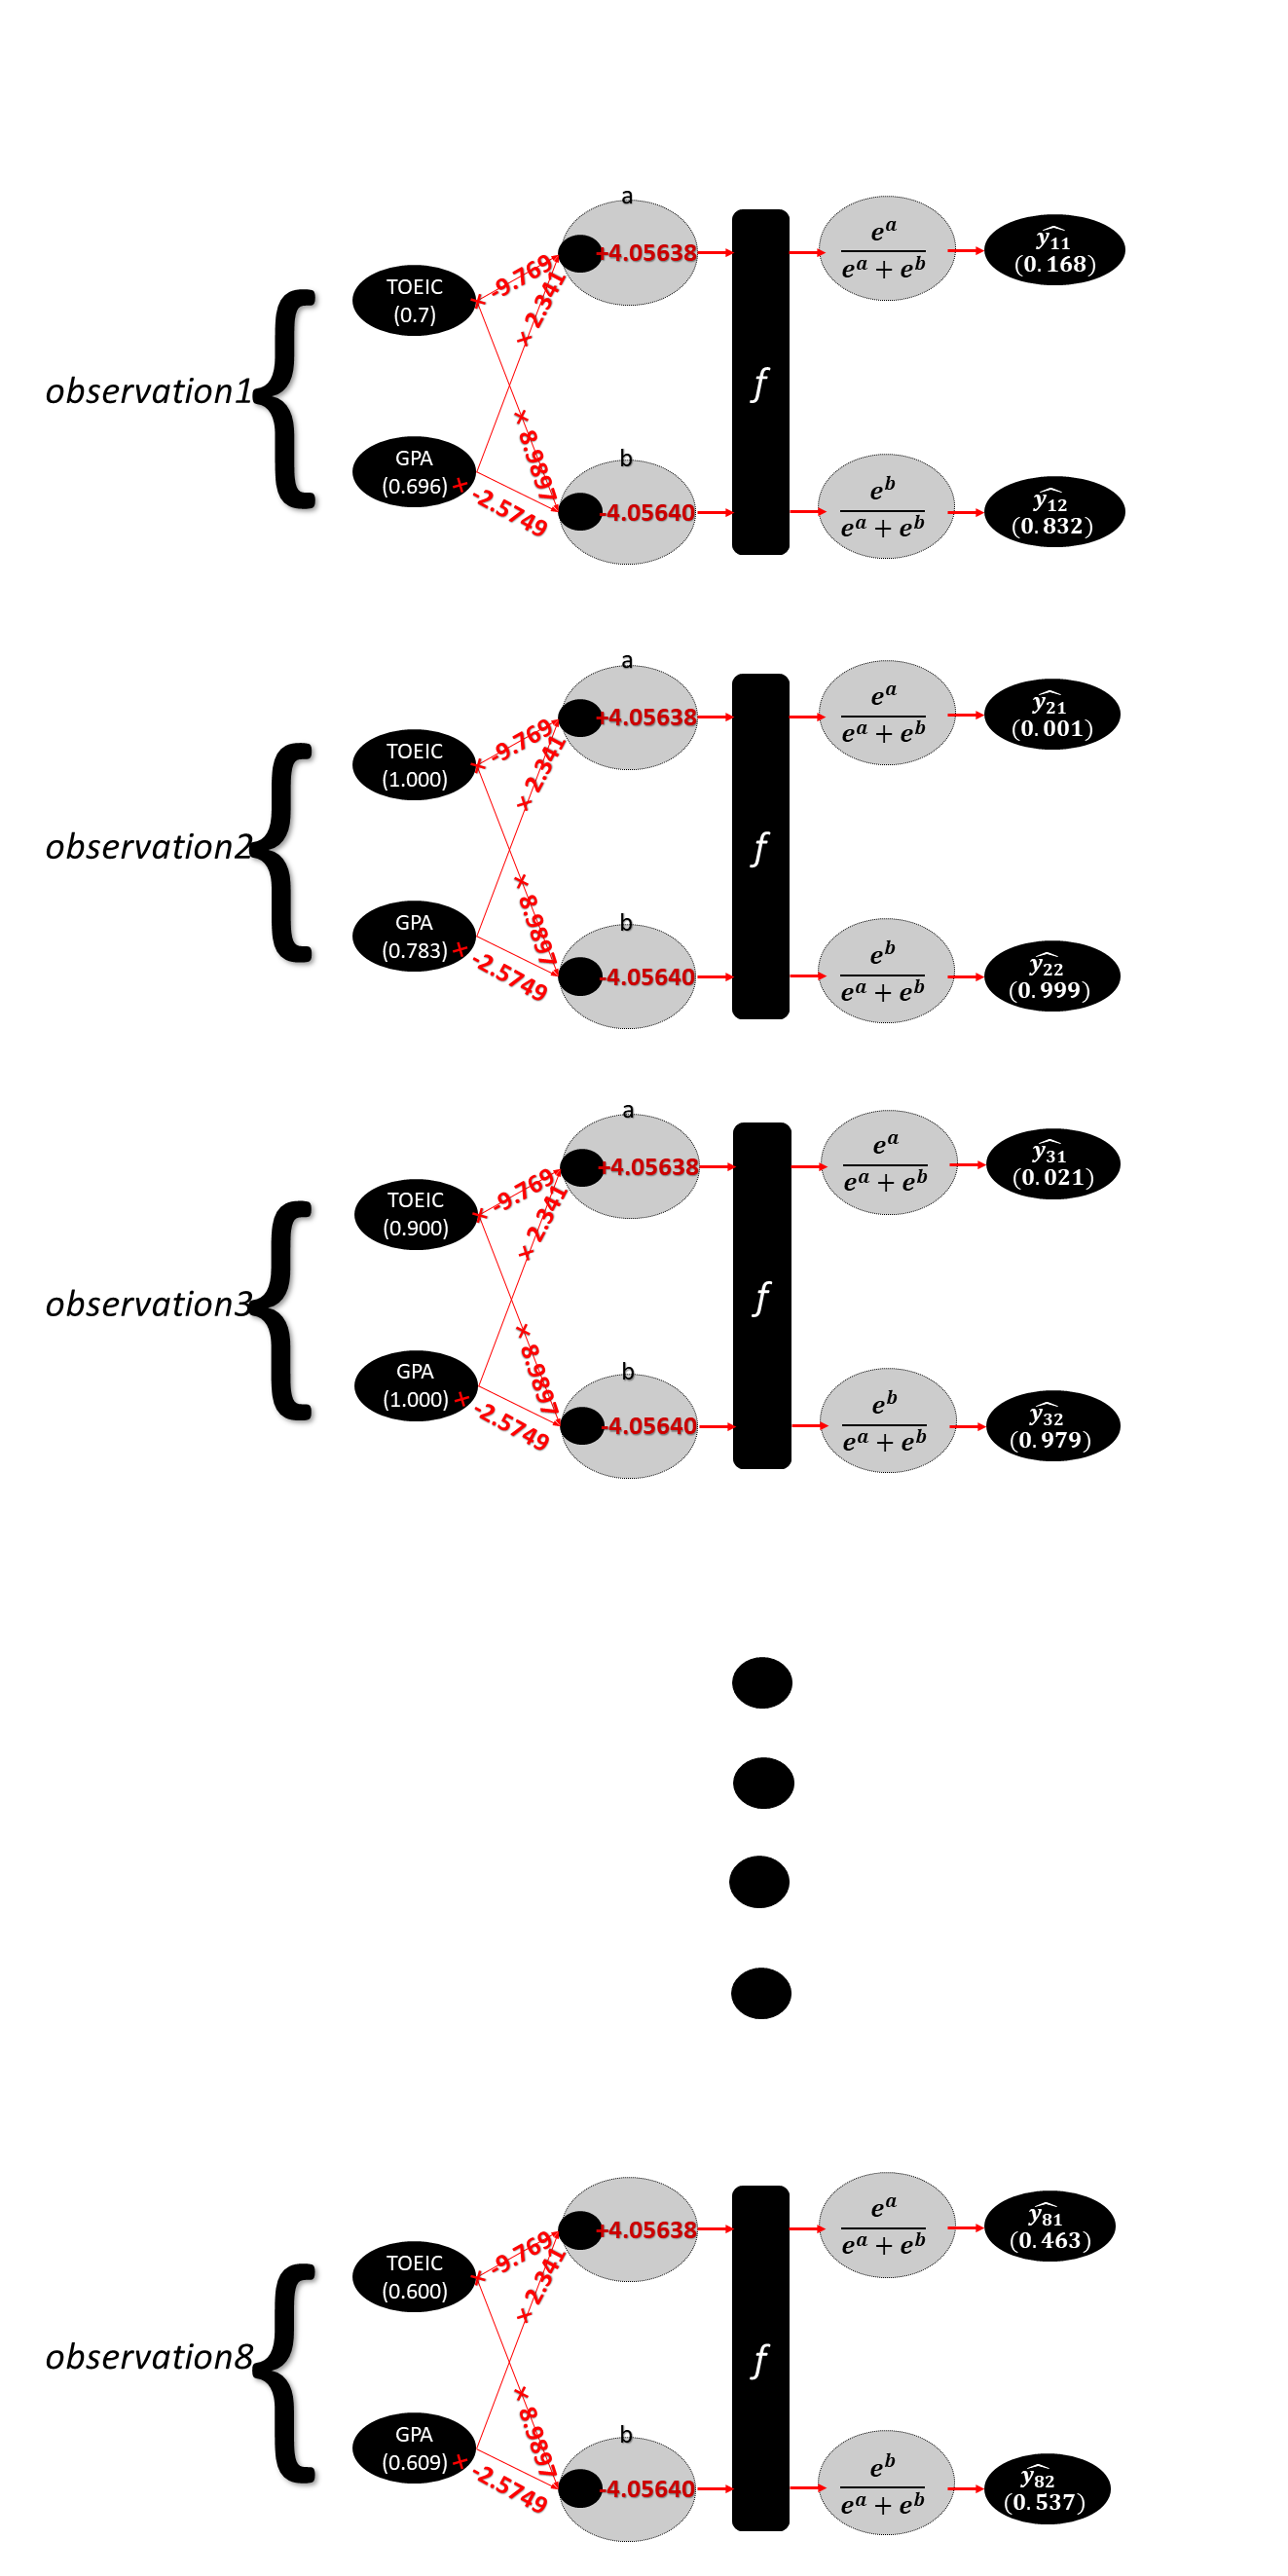

`–` 수식으로 표현하면 아래와 같다. 

`-` ${\bf X}=\begin{bmatrix}
0.700 & 0.696 \\ 
1.000 & 0.783 \\ 
0.900 & 1.000 \\ 
\dots & \dots \\
0.600 & 0.609 
\end{bmatrix}$

`–` ${\bf y}=\begin{bmatrix}
0 & 1 \\
0 & 1 \\
0 & 1 \\
\dots & \dots \\ 
1 & 0 
\end{bmatrix}$

`–` $\hat{\bf W}=\begin{bmatrix} 
- 9.769 & 8.9897\\ 
2.341 & -2.5749 
\end{bmatrix}$

`-` $\hat{\bf b}=\begin{bmatrix} 4.05638 \\ -4.05640 \end{bmatrix}$ 

`–` 결국 모형은 

${\bf y} \approx f\big({\bf XW} +{\bf b} \big)$ 

`-` 예측 혹은 적합을 하기 위해서는 

$\hat{\bf y}=f\big({\bf X}\hat{\bf W}+\hat{\bf b}\big)$

- $({\bf X},{\bf y})$ $\to$ $\hat{\bf W}$ $\to$ $f\big({\bf x}^*{\bf \hat{W}}\big)$ 의 과정에서 ${\bf x}^*$ 가 ${\bf X}$ 에 포함된 관측치라면 적합, 아니라면 예측. 

`-` 결국 아래의 과정에서 우리가 기다린 시간만큼
```
Epoch 1/10000
1/1 [==============================] - 0s 578us/step - loss: 0.8765
Epoch 2/10000
1/1 [==============================] - 0s 571us/step - loss: 0.8740
```
$\hat{\bf W}$, $\hat{\bf b}$의 값을 미세조정 하고 있었던것! 

`–` 회귀분석의 기억을 떠올리면 

${\bf X}=\begin{bmatrix}
1 & 0.700 & 0.696 \\ 
1 & 1.000 & 0.783 \\ 
1 & 0.900 & 1.000 \\ 
\dots & \dots & \dots \\
1 & 0.600 & 0.609 
\end{bmatrix}$, 

$\hat{\bf W}=\begin{bmatrix} 
4.05638 & -4.05640 \\  
- 9.769 & 8.9897\\ 
2.341 & -2.5749 
\end{bmatrix}$

${\bf y} \approx f\big({\bf XW}\big)$

와 같이 쓸 수 있다. 

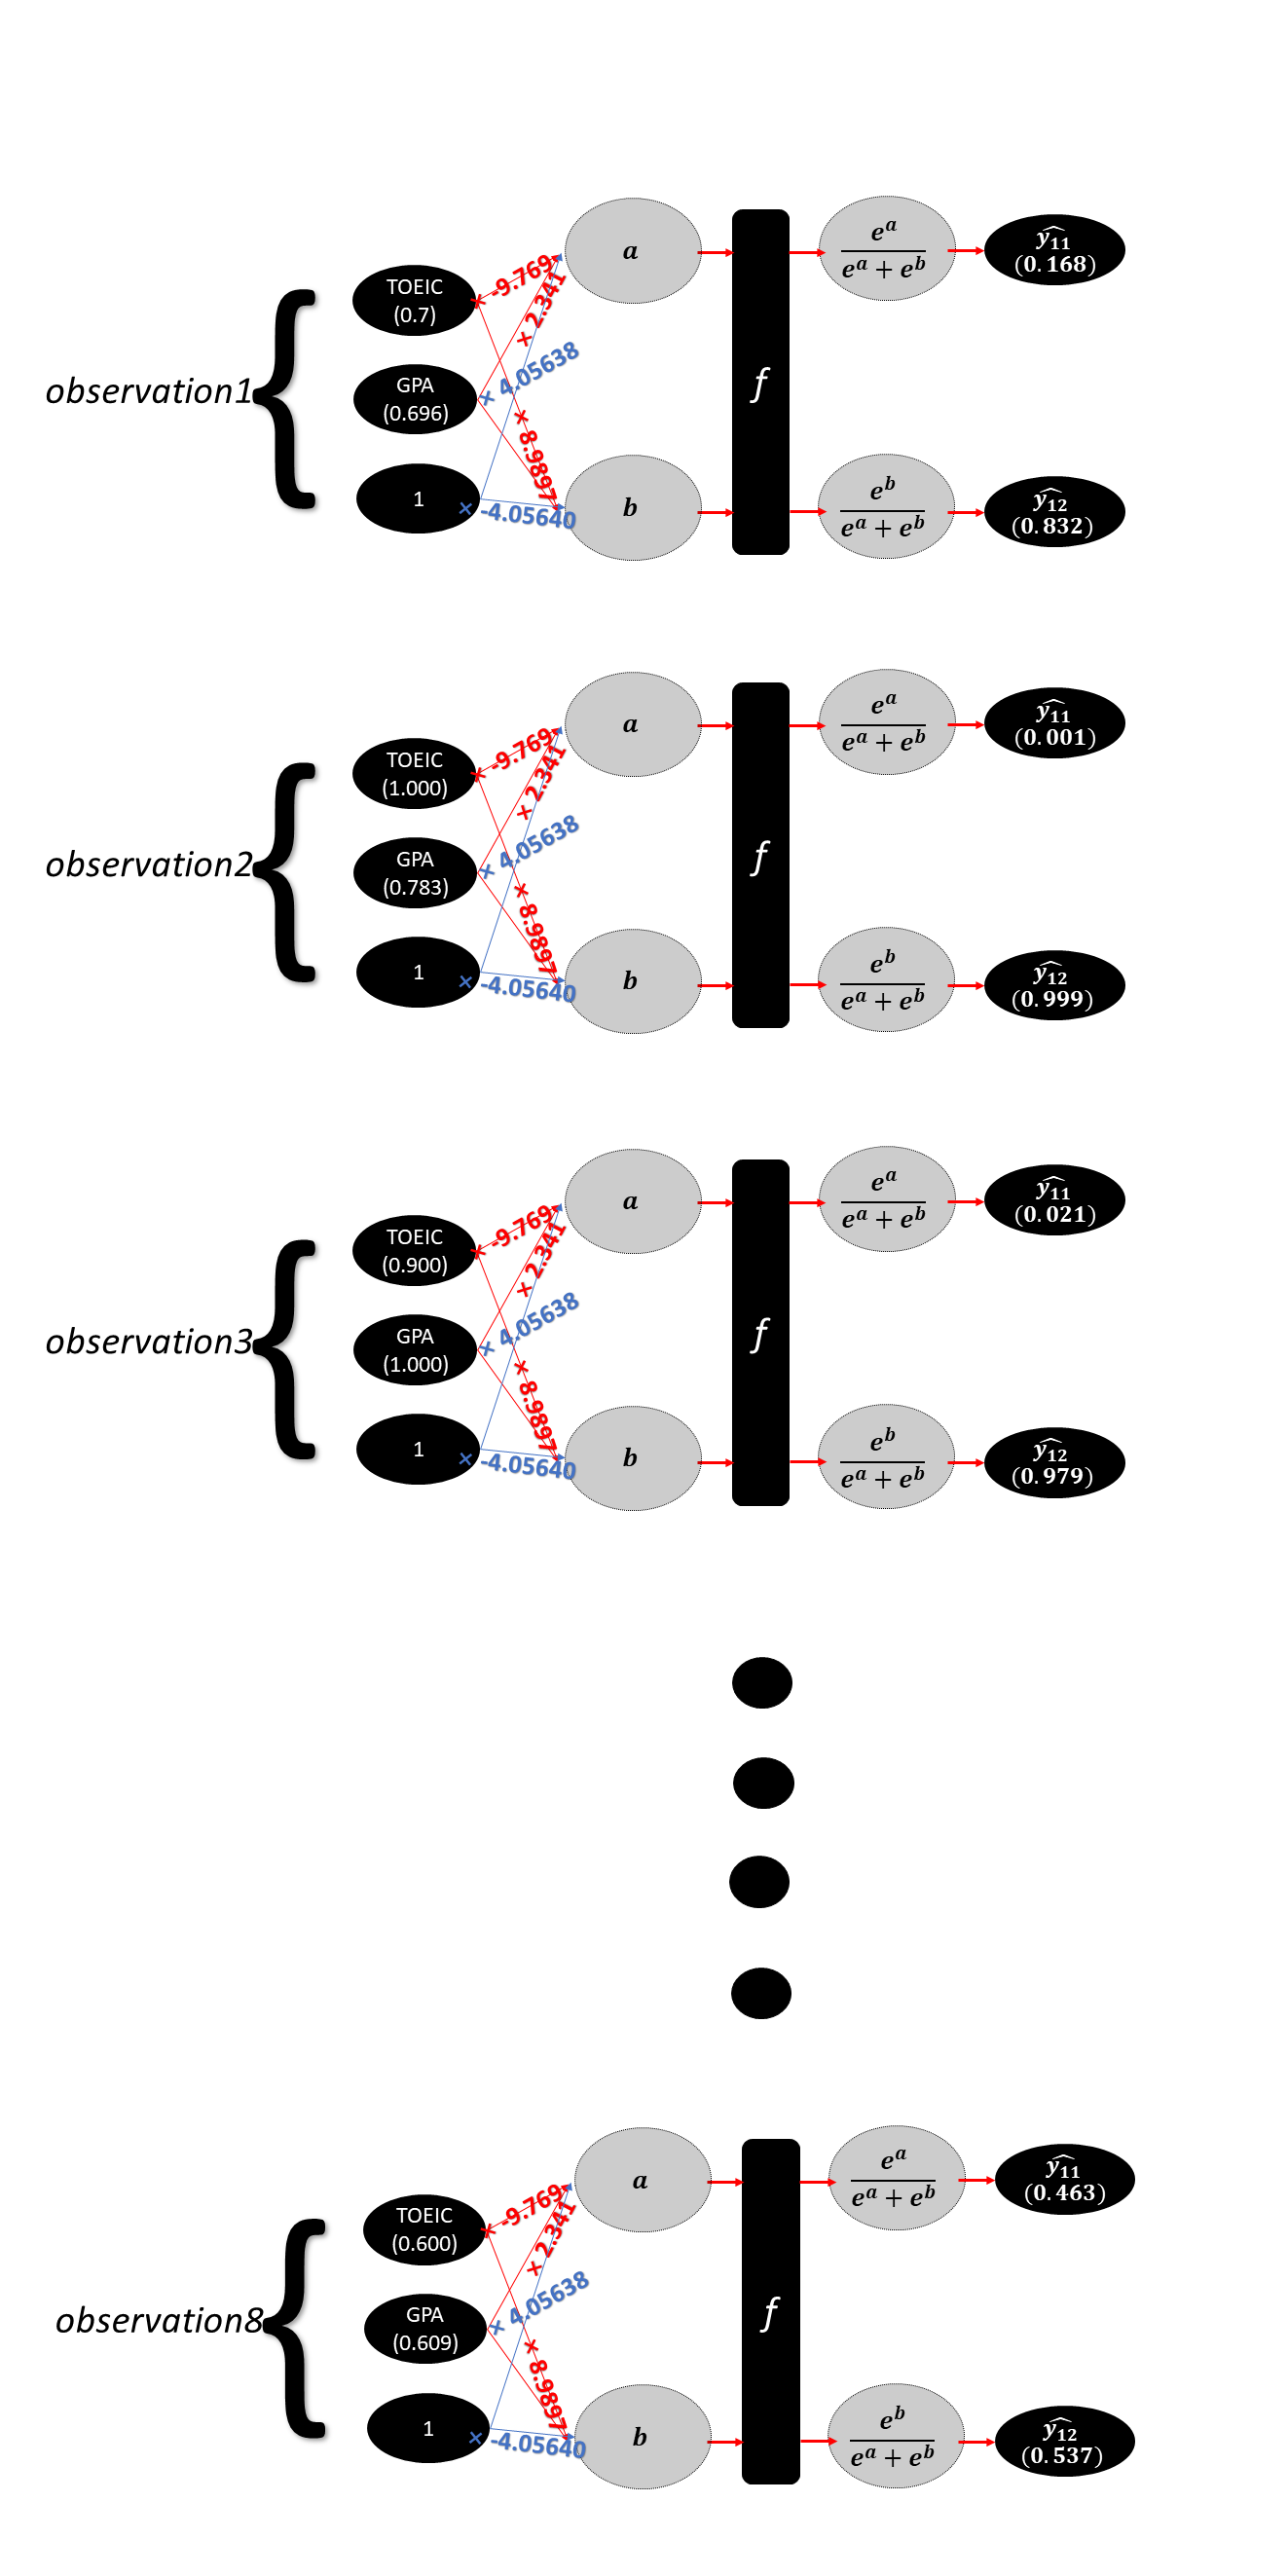

`-` 위의 구조를 좀더 간략하게 도식화하자. observation 1~8 까지는 동일한 그림이므로 observation 1만 고려하자.  

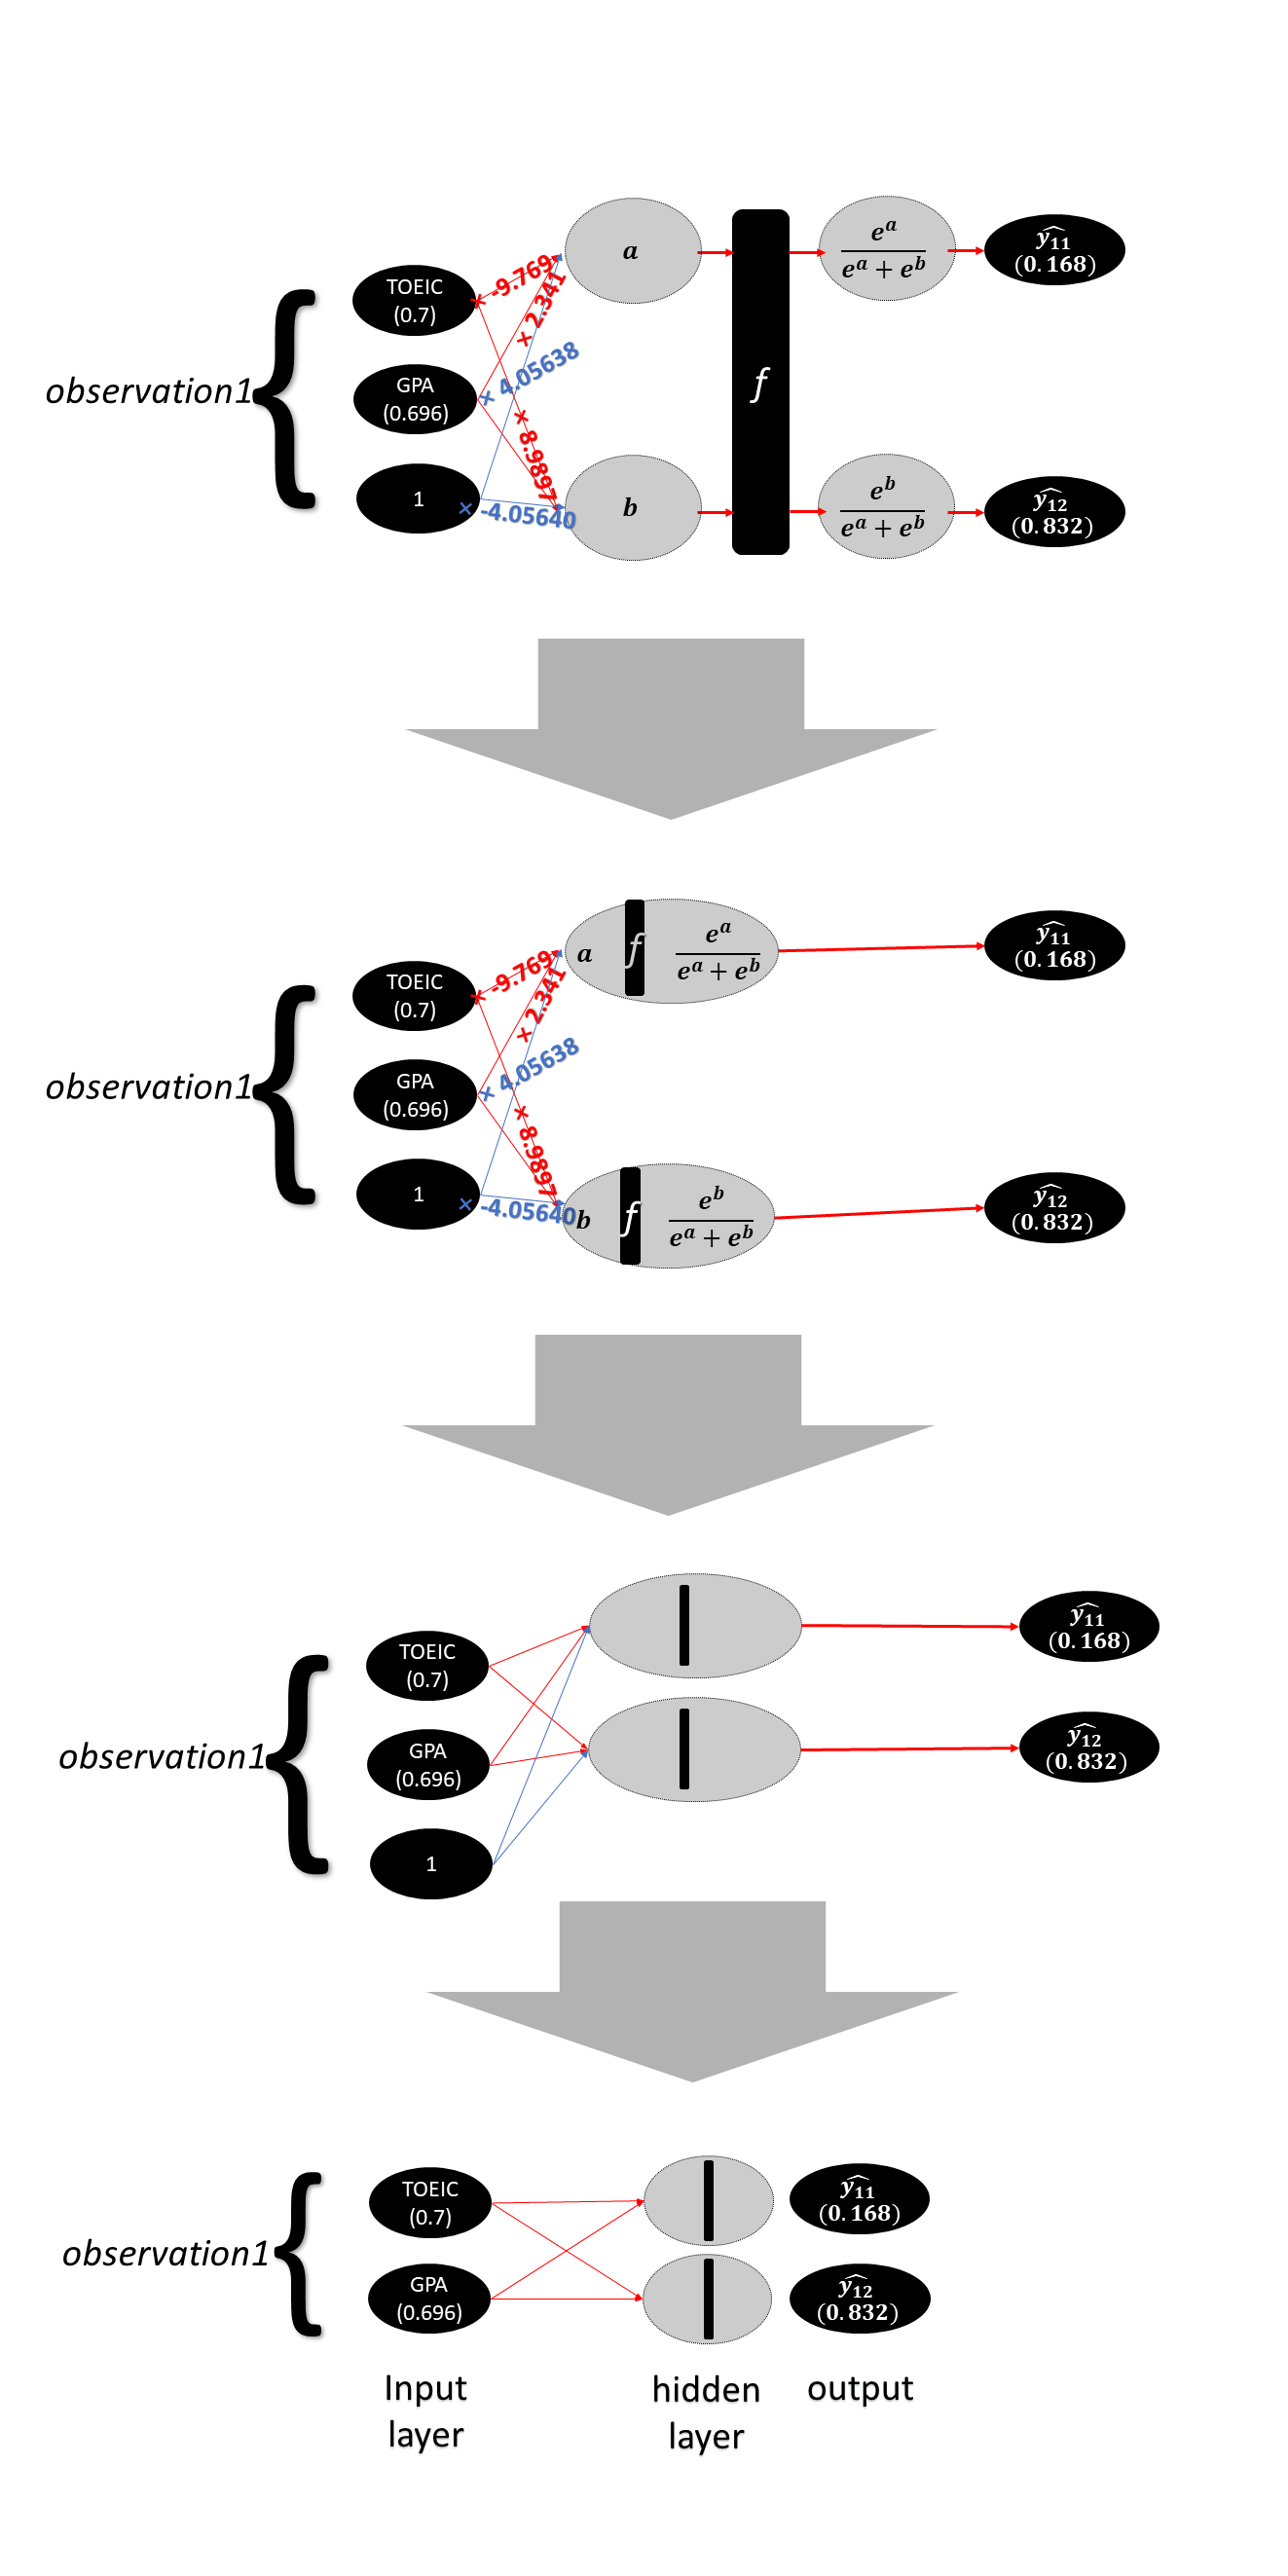

#### Step1: 자료확보

In [126]:
%R -o toeic,gpa,employed

In [127]:
toeic,gpa,employed

(array([673., 727., 771., 658., 766., 752., 757., 839., 652., 851., 690.,
        660., 693., 770., 762., 725., 674., 698., 848., 766., 704., 675.,
        734., 617., 711., 691., 843., 831., 744., 659., 822., 818., 808.,
        809., 722., 806., 854., 753., 672., 814., 813., 725., 886., 686.,
        778., 569., 737., 840., 714., 678., 808., 685., 771., 611., 637.,
        714., 667., 859., 823., 687., 796., 823., 771., 778., 844., 712.,
        716., 826., 647., 765., 747., 787., 832., 771., 769., 810., 847.,
        781., 671., 737., 889., 722., 805., 848., 814., 749., 768., 679.,
        785., 679., 682., 671., 698., 834., 719., 744., 713., 793., 825.,
        733., 799., 718., 834., 798., 831., 799., 767., 598., 695., 789.,
        713., 728., 717., 880., 692., 714., 751., 767., 765., 746., 630.,
        779., 791., 711., 804., 689., 781., 697., 612., 843., 805., 761.,
        869., 619., 760., 558., 866., 680., 645., 680., 657., 591., 671.,
        738., 823., 783., 651., 699., 

#### Step2: X,y 재정의

In [128]:
X=np.array([toeic,gpa]).transpose()
y=employed

In [129]:
X.shape

(1000, 2)

In [130]:
y.shape

(1000,)

#### Step3: 데이터 전처리

데이터 전처리: 기계가 학습하기 좋은 형태로 데이터를 가공하는 과정을 의미

In [131]:
from sklearn.preprocessing import *
onehot=OneHotEncoder()
mms=MinMaxScaler()

In [132]:
mms.fit(X)
X=mms.transform(X)

In [133]:
onehot.fit(y.reshape(-1,1))
y=onehot.transform(y.reshape(-1,1)).toarray()

In [134]:
X,y

(array([[0.34639175, 0.57894737],
        [0.45773196, 0.36842105],
        [0.54845361, 0.36842105],
        ...,
        [0.        , 0.57894737],
        [0.7443299 , 0.73684211],
        [0.62268041, 0.63157895]]),
 array([[1., 0.],
        [1., 0.],
        [1., 0.],
        ...,
        [1., 0.],
        [0., 1.],
        [0., 1.]]))

#### Step4: 모델을 설정

**[필요한 패키지 로드]**

In [135]:
import tensorflow as tf

**[레이어를 설정]**

In [136]:
l1=tf.keras.layers.Dense(2,input_shape=(2,),activation='softmax')

- `2`: 출력층의 차원을 의미 ($y$는 $8\times 2$ matrix)
- `input_shape=(2,)`: 입력의 차원이 2라는 의미임. (toeic, gpa) 이므로.. 
- `activation='softmax'`: activation 함수를 의미함. 우리의 경우는 $f(x)=\frac{e^x}{1+e^x}$를 의미함. 이 예제의 경우 `softmax`를 옵션으로 주면 원하는 결과를 얻는다. 

**[레이어를 여러장 조합하여 모형구축]**

In [137]:
m1=tf.keras.models.Sequential() ## 모델의 틀을 만들고 
m1.add(l1) ## 모델에 레이어 `l1`를 추가함. 
m1.summary() ## 구축된 모형을 요약하여 보여줌. 

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_5 (Dense)              (None, 2)                 6         
Total params: 6
Trainable params: 6
Non-trainable params: 0
_________________________________________________________________


#### Step5: 모델컴파일 (손실함수설정) 

In [138]:
m1.compile(loss='categorical_crossentropy')

#### Step6: 학습

In [145]:
m1.fit(X,y,epochs=10000,verbose=False)

#### Step7: 적합/예측

In [146]:
m1.predict(X),y

(array([[9.9827504e-01, 1.7249541e-03],
        [9.9646437e-01, 3.5355752e-03],
        [7.7702206e-01, 2.2297794e-01],
        ...,
        [1.0000000e+00, 8.9761122e-11],
        [7.4528472e-08, 9.9999988e-01],
        [2.7855102e-04, 9.9972147e-01]], dtype=float32),
 array([[1., 0.],
        [1., 0.],
        [1., 0.],
        ...,
        [1., 0.],
        [0., 1.],
        [0., 1.]]))

In [147]:
m1.weights

[<tf.Variable 'dense_5/kernel:0' shape=(2, 2) dtype=float32, numpy=
 array([[-24.169983,  24.25219 ],
        [-10.937853,  11.253404]], dtype=float32)>,
 <tf.Variable 'dense_5/bias:0' shape=(2,) dtype=float32, numpy=array([ 17.990717, -17.990723], dtype=float32)>]

> Note: 데이터가 적을때와 비교하여 계수값이 차이가 있다. (overfitting 이슈가 해결됨)